### 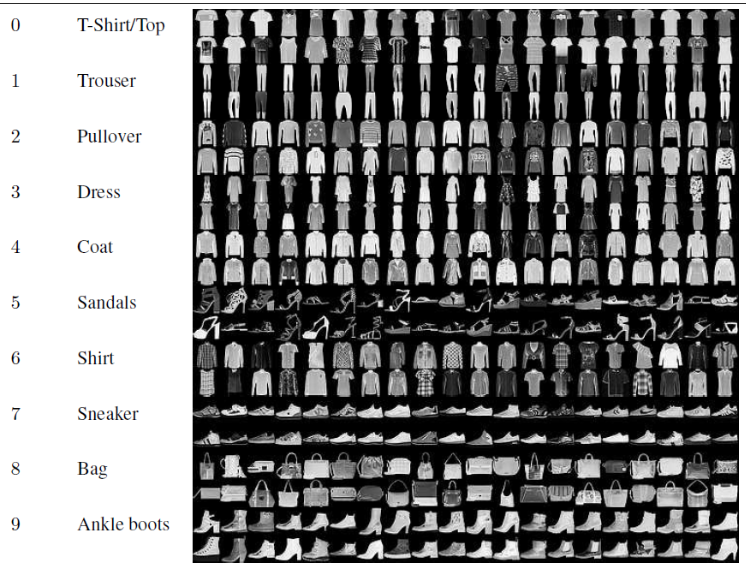

In [1]:
import tensorflow as tf

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
from tensorflow.keras.models import Model

In [6]:
from tensorflow.keras.layers import Input, Flatten, Dense

In [7]:
from tensorflow.keras.datasets import fashion_mnist

In [8]:
(X_train, y_train), (X_test, y_test ) = fashion_mnist.load_data()

In [9]:
X_train.shape

(60000, 28, 28)

In [10]:
X_test.shape

(10000, 28, 28)

In [11]:
names = ["T-Shirt", "Trouser", "Pull Over", "Dess", "Coat", "Sandal", "Shirt", "Sneakers", "Bag", "Ankle Boots"]

In [12]:
names

['T-Shirt',
 'Trouser',
 'Pull Over',
 'Dess',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneakers',
 'Bag',
 'Ankle Boots']

In [13]:
X_train[1000]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  97,  84,
         97, 110, 108,  87,  97,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  19, 255, 199,
        183, 142, 161, 200, 213,  32,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  72, 174, 173,
        158, 131, 132, 176, 176,  70,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 142, 180, 163,
        120, 180, 126, 139, 168, 122,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 156, 180, 162,
        171, 170, 183, 163, 169, 144,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 159, 177, 163,
        174, 166, 173, 170, 163, 148,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [14]:
y_train[1000]

np.uint8(1)

In [15]:
names[1]

'Trouser'

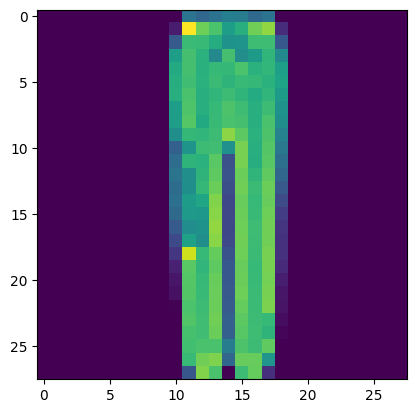

In [16]:
plt.imshow(X_train[1000])

In [17]:
X_test.shape

(10000, 28, 28)

In [18]:
X_test[5000]

array([[  0,   0,   0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   1,   1,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   2,  96, 224, 120,  59,
         59,  57,  63, 127, 216,  46,   0,   0,   0,   1,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 161, 233, 221, 215, 249, 249,
        234, 233, 248, 242, 205, 231, 195,  63,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 176, 251, 222, 225, 204, 190, 201,
        207, 208, 199, 194, 220, 227, 235, 245,  71,   0,   1,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  15, 233, 226, 226, 225, 239, 240, 227,
        218, 209, 219, 239, 228, 225, 223, 241, 175,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  77, 249, 226, 230, 229, 228, 219, 164,
        171, 246, 223, 222, 223, 230, 229, 234, 219,   0,   0,   0,   0,
          0,   0],
       [  

In [19]:
y_test[5000]

np.uint8(2)

In [20]:
names[2]

'Pull Over'

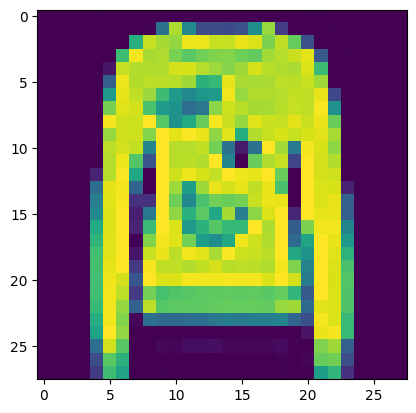

In [21]:
plt.imshow(X_test[5000])

### Scaling

In [22]:
X_train.max()

np.uint8(255)

In [23]:
X_train.min()

np.uint8(0)

In [24]:
X_test.max()

np.uint8(255)

In [25]:
X_test.min()

np.uint8(0)

In [26]:
X_train_scale = X_train/ 255

In [27]:
X_test_scale = X_test / 255

In [28]:
X_train_scale.max()

np.float64(1.0)

In [29]:
X_test_scale.max()

np.float64(1.0)

In [30]:
X_train_scale.min()

np.float64(0.0)

In [31]:
X_test_scale.min()

np.float64(0.0)

In [32]:
X_train[500]

array([[  0,   0,   0,   0,   0,   0,   0,   3,   0,   0,   0,  19, 204,
         93,  35,  91, 227,  91,   0,   0,   0,   3,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   2,   0,   0, 134, 210, 237, 241,
        241, 255, 245, 238, 241, 248, 111,   0,   0,   3,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 175, 254, 235, 233, 232,
        225, 227, 226, 229, 231, 236, 250, 200,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   2, 240, 229, 228, 219, 215,
        235, 229, 234, 217, 198, 222, 220, 255, 101,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  46, 246, 236, 189, 173, 212,
        240, 226, 239, 210, 152, 177, 222, 249, 170,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  97, 255, 233, 226, 231, 237,
        230, 231, 231, 236, 241, 232, 231, 245, 210,   0,   0,   0,   0,
          0,   0],
       [  

In [33]:
X_train_scale[500]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.01176471, 0.        , 0.        ,
        0.        , 0.0745098 , 0.8       , 0.36470588, 0.1372549 ,
        0.35686275, 0.89019608, 0.35686275, 0.        , 0.        ,
        0.        , 0.01176471, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00784314, 0.        , 0.        , 0.5254902 ,
        0.82352941, 0.92941176, 0.94509804, 0.94509804, 1.        ,
        0.96078431, 0.93333333, 0.94509804, 0.97254902, 0.43529412,
        0.        , 0.        , 0.01176471, 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.68627451, 0.99607843,
        0.92156863, 0.91372549, 0.90980392, 0.88235294, 0.89019608,
        0.88627451, 0.8980

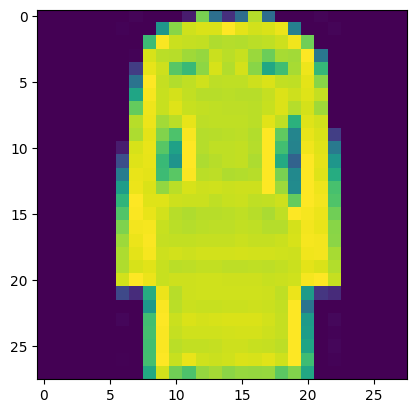

In [34]:
plt.imshow(X_train[500])

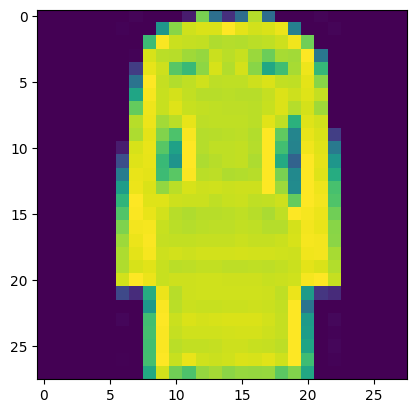

In [35]:
plt.imshow(X_train_scale[500])

In [36]:
X_train.shape

(60000, 28, 28)

In [37]:
X_train_scale.shape

(60000, 28, 28)

In [38]:
X_test.shape

(10000, 28, 28)

In [39]:
X_test_scale.shape

(10000, 28, 28)

### Functional Model

In [40]:
from tensorflow.keras.models import Model

In [41]:
from tensorflow.keras.layers import Input, Dense, Flatten

In [42]:
X_train_scale.shape

(60000, 28, 28)

In [43]:
ip = Input(shape = (28,28))

In [44]:
flat = Flatten()(ip)

In [45]:
den1 = Dense(128, activation = "relu")(flat)

In [46]:
den2 = Dense(256, activation = "relu")(den1)

In [47]:
den3 = Dense(512, activation = "relu")(den2)

In [48]:
out = Dense(10, activation = "softmax")(den3)

In [49]:
fmodel = Model(inputs = ip, outputs = out)

In [50]:
fmodel.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,218 (1.03 MB)

 Trainable params: 270,218 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
fmodel.compile(
                optimizer = "adam",
                loss = "sparse_categorical_crossentropy",
                metrics = ['accuracy']                        
                    )

In [52]:
fmodel.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.7204 - loss: 1.1328
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7868 - loss: 0.5717
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8187 - loss: 0.4943
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8382 - loss: 0.4567
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8461 - loss: 0.4380
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8493 - loss: 0.4252
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8541 - loss: 0.4113
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8496 - loss: 0.4077
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8553 - loss: 0.4051
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8546 - loss: 0.3912
